# AI Agent Prototyping

![image.png](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit1/coffee-please.jpg)



![image.png](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit1/reason-and-plan.jpg)

(Images from the Hugging Face AI Agent Course https://huggingface.co/learn/agents-course/unit1/what-are-agents)
### The general process, or "cognitive loop," that Smolagent formalizes usually looks like this:

1. Define a Goal: The user provides a high-level objective.

2. Plan: The Language Model (LLM), acting as a "Planner," breaks the objective down into a sequence of concrete, executable steps. This plan is often a numbered list of actions.

3. Execute with Tools: The agent iterates through the plan. For each step, it determines if it needs an external tool (like a web search, a calculator, or a code interpreter). If a tool is needed, the "Tool User" component executes it.

4. Observe and Update: The agent takes the result of the tool's execution (e.g., the text from a search result) and feeds it back into its context.

5. Reason and Refine: The LLM processes the new information, synthesizes it with what it already knows, refines its understanding, and decides on the next step. It might even update the original plan based on new findings.

6. Repeat until Goal is Met: The agent continues this Plan -> Execute -> Observe -> Reason loop until it determines the original goal is complete, at which point it generates a final answer.

## Let's install the dependencies and login to our HF account to access the Inference API

If you haven't installed `smolagents` yet, you can do so by running the following command:the dependencies and login to our HF account to access the Inference API


In [18]:
!pip install 'smolagents[openai]'
!pip install ddgs
!pip install opensearch-py

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 10.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 1.4 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 1.4 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.2/352.2 kB 6.4 MB/s eta 0:00:00:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Let's also login to the Hugging Face Hub to have access to the Inference API.

#### **Set Up Hugging Face API Token**

The agent uses a powerful language model from the Hugging Face Hub. To access it, you need an API token.

1.  If you don't have one, create a free Hugging Face account and get a token from your [**profile settings**](https://huggingface.co/settings/tokens).
2.  Run the cell below. A text field will appear.
3.  Paste your token into the field and press Enter. The token will be hidden for security.

This will load the token and initialize the agent's brain (the language model).

In [7]:
# Prompt for the Hugging Face API token
import getpass
import os
from smolagents.models import InferenceClientModel
hf_token = getpass.getpass('🔑 Please enter your Hugging Face API token: ')
os.environ['HF_TOKEN'] = hf_token

if hf_token:
    print("✅ Hugging Face API token has been set.")
else:
    print("⚠️ Hugging Face API token was not provided.")

# Initialize the model that will power our agent
model = InferenceClientModel()

print("🤖 Model initialized.")

🔑 Please enter your Hugging Face API token:  ········


✅ Hugging Face API token has been set.
🤖 Model initialized.


You can also use local hosted LLMs from vLLM or ollama, or use the other models through API:

In [19]:
from smolagents import CodeAgent, InferenceClientModel, OpenAIServerModel
# Replace with your vLLM endpoint details
vllm_model_name = ""
vllm_api_base = ""
vllm_api_key = ""

openai_model_name = ""
openai_api_base = ""
openai_api_key = ""

# Initialize the model using OpenAIServerModel to connect to vLLM
# Sometimes the API base should be the base URL, not including the /v1/chat/completions part
# model = OpenAIServerModel(
#     model_id=vllm_model_name,
#     api_base=vllm_api_base,
#     api_key=vllm_api_key,
# )

model = OpenAIServerModel(
    model_id=openai_model_name,
    api_base=openai_api_base,
    api_key=openai_api_key,
)

Define Spatial Tools

In [15]:
# Cell 3: Define Spatial Tools
import os
import pandas as pd
from smolagents import CodeAgent, tool
from smolagents.models import InferenceClientModel
#from duckduckgo_search import DDGS
import getpass
import geopandas as gpd
import matplotlib.pyplot as plt
from ddgs import DDGS
@tool
def load_chicago_community_areas() -> gpd.GeoDataFrame:
    """
    Loads the official boundaries for Chicago's 77 community areas.
    Returns a GeoDataFrame with geometry and community area information.
    """
    url = 'https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/refs/heads/master/data/chicago-community-areas.geojson'
    return gpd.read_file(url)
@tool
def load_chicago_crime_data() -> gpd.GeoDataFrame:
    """
    Loads reported crime incidents in Chicago from the last 365 days.
    The data includes coordinates for each crime, which can be used for mapping.
    Returns a GeoDataFrame with crime details and point geometries.
    """
    # Socrata API endpoint for crime data.
    # The space ' ' is encoded as %20 and the greater-than '>' is encoded as %3E.
    url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json?$where=date%20%3E%20'2024-08-13T00:00:00.000'&$limit=50000"
    df = pd.read_json(url)
    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
    )
    return gdf
@tool
def filter_dataframe_by_value(df: pd.DataFrame, column: str, value: str) -> pd.DataFrame:
    """
    Filters a DataFrame to only include rows where the specified column matches a certain value.
    This is useful for isolating specific types of crime, for example.
    Args:
        df: The DataFrame to filter.
        column: The name of the column to check.
        value: The value to match in the column.
    Returns:
        A filtered DataFrame.
    """
    return df[df[column].str.upper() == value.upper()]

@tool
def spatial_join_and_count(gdf_polygons: gpd.GeoDataFrame, gdf_points: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Performs a spatial join, counting how many points from one GeoDataFrame fall within the polygons of another.
    For example, it can count the number of thefts (points) in each community area (polygons).
    Args:
        gdf_polygons: The GeoDataFrame with polygons (e.g., community areas).
        gdf_points: The GeoDataFrame with points to be counted (e.g., crimes).
    Returns:
        The polygon GeoDataFrame with a new 'crime_count' column.
    """
    # Ensure both GeoDataFrames use the same CRS
    gdf_points = gdf_points.to_crs(gdf_polygons.crs)
    # Perform the spatial join
    joined_gdf = gpd.sjoin(gdf_polygons, gdf_points, how="left", predicate='contains')
    # Count points in each polygon
    point_counts = joined_gdf.groupby('community').size()
    point_counts.name = 'crime_count'
    # Merge the counts back into the original polygon gdf
    result_gdf = gdf_polygons.merge(point_counts, left_on='community', right_index=True, how='left').fillna(0)
    result_gdf['crime_count'] = result_gdf['crime_count'].astype(int)
    return result_gdf

@tool
def plot_choropleth_map(gdf: gpd.GeoDataFrame, column: str, title: str) -> None:
    """
    Generates and displays a choropleth map, where polygons are colored based on a numeric value.
    This is excellent for visualizing data like crime rates across different areas.
    Args:
        gdf: The GeoDataFrame containing the geographic data and the values to plot.
        column: The name of the column to use for coloring the polygons.
        title: The title to display above the map.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    gdf.plot(column=column, ax=ax, legend=True,
             legend_kwds={'label': "Number of Crimes", 'orientation': "horizontal"})
    ax.set_title(title, fontdict={'fontsize': '16', 'fontweight': '3'})
    ax.set_axis_off()
    plt.show()

print("✅ Agent's spatial tools are defined.")
# Cell 3: Define Geospatial Resource Discovery Tools

@tool
def search_geospatial_resources(topic: str, resource_type: str) -> list:
    """
    Searches for geospatial resources like datasets, notebooks, or publications on a given topic.

    Args:
        topic: The geospatial topic to search for.
        resource_type: The type of resource to find ('datasets', 'notebooks', or 'publications').

    Returns:
        A list of search results with titles, links, and snippets.
    """
    query_map = {
        'datasets': f'geospatial open data {topic}',
        'notebooks': f'jupyter notebook {topic} github',
        'publications': f'research paper {topic} pdf'
    }
    query = query_map.get(resource_type, f'geospatial {topic}')

    with DDGS() as ddgs:
        results = list(ddgs.text(query, max_results=5))
    return results

@tool
def analyze_and_organize_results(results: list, topic: str) -> str:
    """
    Analyzes a list of search results using an LLM to determine quality and relevance.
    It then organizes the extracted metadata into a Markdown table.

    Args:
        results: A list of search results from the search_geospatial_resources tool.
        topic: The original geospatial topic for context.

    Returns:
        A Markdown formatted string with the organized metadata.
    """
    if not results:
        return "No results to analyze."

    analysis_prompt = f"""
    Analyze the following search results about '{topic}'. For each result, determine its relevance and quality.
    Extract the title, a brief summary, and the direct URL. Format the output as a clean Markdown table
    with columns: 'Title', 'Summary', and 'URL'.

    Results:\n{results}
    """

    # This is a simplified call to the model. In a real scenario, you might have a more complex
    # function to interact with the LLM and parse its output robustly.
    response = model.generate(analysis_prompt)

    return response

print("✅ Agent's resource discovery tools are defined.")

✅ Agent's spatial tools are defined.
✅ Agent's resource discovery tools are defined.


In [21]:
# Initialize the agent
agent = CodeAgent(tools=[
        load_chicago_community_areas,
        load_chicago_crime_data,
        filter_dataframe_by_value,
        spatial_join_and_count,
        plot_choropleth_map,
        search_geospatial_resources,
        analyze_and_organize_results,], model=model)
response = agent.run(
    "What are the risks of aging dams?"
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What are the risks of aging dams?                                                                               │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  results = search_geospatial_resources(topic="risks of aging dams", resource_type="publications")                 
  print(results)                                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
[{'title': 'ResearchGate (PDF) Dam ageing diagnosis and risk analysis: Development of methods to support expert 
judgment', 'href': 
'https://www.researchgate.net/publication/237372530_Dam_ageing_diagnosis_and_risk_analysis_Development_of_methods_t
o_support_expert_judgment', 'body': 'January 25, 2011 - PDF | Diagnosis and risk analysis are essential to ensure 
the safety of dams . Dam specialist engineers have useful methods available to help them in... | Find, read and 
cite all the research you need on ResearchGate'}, {'title': 'Science4Data The Growing Threat of Aging Dams and 
Climate Risks - Science4Data', 'href': 
'https://www.science4data.com/climate-change-and-aging-dams-rising-failure-risks-in-the-us/', 'body': 'October 15, 
2024 - The recent flooding induced by Hurricane Helene has put a spotlight on the risk of dam failure in the United
States due to increased precipitation levels linked to climate change. Particularly under threat were multiple dams
, including Nolichucky Dam in Tennessee and Walters and Lake Lure dams ...'}, {'title': 'Academia.edu (PDF) Ageing 
Water Storage Infrastructure: An Emerging Global Risk', 'href': 
'https://www.academia.edu/47770218/Ageing_Water_Storage_Infrastructure_An_Emerging_Global_Risk', 'body': 'April 28,
2021 - Academia.edu is a platform for academics to share research papers .'}, {'title': 'Taylor & Francis Online 
Full article: ‘Literature review on the analysis of climate change risks in the environmental impact assessment of 
dams’', 'href': 'https://www.tandfonline.com/doi/full/10.1080/14615517.2021.1893928', 'body': 'Climate change is a 
current concern in our society, with consequences increasingly felt worldwide. Alongside territories and 
communities, large infrastructures such as dams may be vulnerable to cli...'}, {'title': 'PreventionWeb Ageing dams
pose growing threat: UN | PreventionWeb', 'href': 
'https://www.preventionweb.net/news/ageing-dams-pose-growing-threat-un', 'body': 'January 26, 2021 - The report, “ 
Ageing water infrastructure: An emerging global risk ,” by UNU’s Canadian-based Institute for Water, Environment 
and Health, says most of the 58,700 large dams worldwide were constructed between 1930 and 1970 with a design life 
of 50 to 100 years, adding that at 50 years, ...'}]

Out: None

[Step 1: Duration 3.11 seconds| Input tokens: 2,456 | Output tokens: 97]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  risk_summary = (                                                                                                 
      "The risks of aging dams include:\n"                                                                         
      "1. Structural failure due to aging materials and design limitations.\n"                                     
      "2. Increased susceptibility to climate change impacts, including extreme weather and flooding.\n"           
      "3. Limited maintenance and upgrades as many dams are beyond their designed life (50-100 years).\n"          
      "4. Growing threat to public safety and environmental integrity, especially as recent climate events         
  highlight vulnerabilities."                                                                                      
  )                                                                                                                
  final_answer(risk_summary)                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The risks of aging dams include:
1. Structural failure due to aging materials and design limitations.
2. Increased susceptibility to climate change impacts, including extreme weather and flooding.
3. Limited maintenance and upgrades as many dams are beyond their designed life (50-100 years).
4. Growing threat to public safety and environmental integrity, especially as recent climate events highlight 
vulnerabilities.

[Step 2: Duration 8.23 seconds| Input tokens: 5,632 | Output tokens: 692]

Optional tool: If you have access to the I-GUIDE OpenSearch indes, here is the Python code for  `smolagents` tool that uses the `opensearch-py` library to interact with the OpenSearch instance of the I-GUIDE Platform.

In [13]:
# Define the connection to OpenSearch:
os.environ['OPENSEARCH_NODE'] = ''
os.environ['OPENSEARCH_USERNAME'] = ''
os.environ['OPENSEARCH_PASSWORD'] = ''
os.environ['OPENSEARCH_INDEX'] = ''

In [14]:
from smolagents import Tool
from opensearchpy import OpenSearch
import os

class OpenSearchSearchTool(Tool):
    name = "opensearch_search"
    description = "Searches for documents in the I-GUIDE Platform OpenSearch index based on the keywords from the user query."
    inputs = {
        "query": {
            "type": "string",
            "description": "The query string to search for in the OpenSearch index."
        }
    }
    output_type = "string"

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Initialize the OpenSearch client
        self.client = OpenSearch(
            hosts=[{'host': os.environ.get('OPENSEARCH_NODE'), 'port': 9200}], # Assuming default OpenSearch port
            http_auth=(os.environ.get('OPENSEARCH_USERNAME'), os.environ.get('OPENSEARCH_PASSWORD')),
            use_ssl=True,
            verify_certs=False, # Equivalent to rejectUnauthorized: false
            ssl_assert_hostname=False,
            ssl_show_warn=False,
        )
        self.index_name = os.environ.get('OPENSEARCH_INDEX') # Assuming index name is stored in environment variable


    def forward(self, query: str) -> str: # Changed parameter name from userQuery to query
        assert isinstance(query, str), "Your search query must be a string"

        try:
            response = self.client.search(
                index=self.index_name,
                size=12,
                body={
                    "query": {
                        "match": {
                            "contents": query # Assuming you want to search in a field named 'contents'
                        }
                    }
                }
            )
            # Process hits to remove the 'contents-embedding' field
            hits = response['hits']['hits']
            for hit in hits:
                if '_source' in hit and 'contents-embedding' in hit['_source']:
                    del hit['_source']['contents-embedding']

            # Convert the modified list of hits to a string
            return str(hits)
        except Exception as e:
            print(f"Error connecting to OpenSearch: {e}")
            return f"Error: {e}" # Return error as a string

In [20]:
# # Example usage (assuming you have set the environment variables OPENSEARCH_NODE, OPENSEARCH_USERNAME, OPENSEARCH_PASSWORD, and OPENSEARCH_INDEX)
# # opensearch_tool = OpenSearchSearchTool()
# # search_results = opensearch_tool(userQuery="your search query")
# # print(search_results)
# opensearch_search_tool = OpenSearchSearchTool()

# # Initialize the agent
# agent = CodeAgent(tools=[opensearch_search_tool], model=model)
# response = agent.run(
#     "What are the risks of aging dams."
# )


# Example usage (assuming you have set the environment variables OPENSEARCH_NODE, OPENSEARCH_USERNAME, OPENSEARCH_PASSWORD, and OPENSEARCH_INDEX)
# opensearch_tool = OpenSearchSearchTool()
# search_results = opensearch_tool(userQuery="your search query")
# print(search_results)
opensearch_search_tool = OpenSearchSearchTool()

# Initialize the agent
agent = CodeAgent(tools=[opensearch_search_tool, 
        load_chicago_community_areas,
        load_chicago_crime_data,
        filter_dataframe_by_value,
        spatial_join_and_count,
        plot_choropleth_map,
        search_geospatial_resources,
        analyze_and_organize_results,], model=model)
response = agent.run(
    "What are the risks of aging dams?"
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What are the risks of aging dams?                                                                               │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  risks_of_aging_dams_info = opensearch_search("risks associated with aging dams")                                 
  print(risks_of_aging_dams_info)                                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
[{'_index': 'i_guide_spatial_embedding', '_id': '30c77781-48fc-4602-a126-6c2af39fc298', '_score': 20.22536, 
'_source': {'title': 'Increasing dam failure risk in the USA due to compound rainfall clusters as climate changes',
'contents': 'A changing climate, with intensifying precipitation may contribute to increasing failures of dams by 
overtopping. We present the first analysis of rainfall sequences and events associated with recent hydrologic 
failures of 552 dams in the United States. We find that the maximum 1-day rainfall associated with failure was 
often not extreme compared to dam spillway design criteria, even when accounting for rainfall statistics changing 
with time at each site. However, the combination of the total rainfall 5 to 30 days prior and the maximum 1-day 
rainfall associated with dam failure is rare. Persistent atmospheric circulation patterns that lead to recurrent 
rainfall events, rather than just more moisture in the atmosphere is a possible reason. The probability of these 
compound precipitation risks has increased across much of the country. With over 90,000 aging dams still in 
service, the increasing likelihood of intense rainfall sequences raises concerns about future dam failures.', 
'authors': ['Jeongwoo Hwang', 'Upmanu Lall'], 'tags': ['Dam Failures', 'Climate Change', 'Aging Dams', 'Compound 
Rainfall Events', 'Reservoir Management'], 'resource-type': 'publication', 'thumbnail-image': 
'https://backend.i-guide.io:443/user-uploads/thumbnails/1728781808858-figure_4.png', 'spatial-coverage': [], 
'spatial-geometry': '', 'spatial-bounding-box': '', 'spatial-centroid': '', 'spatial-georeferenced': '', 
'spatial-temporal-coverage': [], 'spatial-index-year': [''], 'contributor': 'Jeongwoo Hwang'}}, {'_index': 
'i_guide_spatial_embedding', '_id': '6775be4b-ed0b-46f2-9461-85ec92026d6c', '_score': 13.578434, '_source': 
{'contributor': 'Fangzheng Lyu', 'contents': "News articles collected by searching words 'aging dams' in Google 
News and news websites. 188 news articles in total.", 'resource-type': 'dataset', 'title': 'Google News Articles - 
Aging Dams', 'authors': ['Wei Hu'], 'tags': ['Aging-Dams', 'HyperCube', 'Dam', 'News'], 'thumbnail-image': 
'https://backend.i-guide.io:443/user-uploads/thumbnails/ds6.png'}}, {'_index': 'i_guide_spatial_embedding', '_id': 
'3b8c4c57-40c9-4bbe-9517-cd646541ae9d', '_score': 9.731093, '_source': {'contributor': 'Fangzheng Lyu', 'contents':
"This study proposes a framework employing spatial metrics (Bivariate Moran's I and LISA) to discover where and 
whether socially vulnerable populations are more exposed to flood inundation risks induced by dam failures. This 
notebook, in particular, demonstrates the socioeconomic characteristics of at-risk populations, focusing on 345 
dams in the conterminous United States.", 'resource-type': 'notebook', 'title': 'Who is facing the risk of 
potential dam failures?', 'authors': ['Jinwoo Park'], 'tags': ['Aging-Dams', 'Infrastructure'], 'thumbnail-image': 
'https://backend.i-guide.io:443/user-uploads/thumbnails/nb5.png'}}, {'_index': 'i_guide_spatial_embedding', '_id': 
'0264e99a-5b93-41d7-a8a2-f5c1210c35cf', '_score': 9.205631, '_source': {'title': 'Aging Dams', 'contents': '<div 
class="tw-container tw-mx-auto tw-px-4 tw-py-6">\n<h3>3 Sentences</h3>\n<hr>\n<p><span style="font-weight: 
400;">The potential for the failure of aging dams requires understanding how changing climate affects the chance of
high precipitation events that could lead to the failure by overtopping the dams. In addition, it requires a 
knowledge of statistics and machine learning to quantify the risk of dam failure and to predict which areas of 
critical infrastructure or populations downstream of the dam. Finally, an understanding of the social and economic 
impacts of dam failure, and of the governance and response planning of the dams is needed through social sciences 
for proper communication, understanding of the chain of events 

[Step 1: Duration 3.51 seconds| Input tokens: 2,513 | Output tokens: 93]

...

[Step 2: Duration 6.45 seconds| Input tokens: 24,124 | Output tokens: 439]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(risks_summary)                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: {'Overtopping Risks': 'Aging dams are at risk of overtopping during intense rainfall events, 
especially due to climate change.', 'Failure Risks': 'The likelihood of dam failures is rising, leading to 
potential disasters for downstream populations.', 'Maintenance and Monitoring': 'Many aging dams lack adequate 
monitoring, increasing the risk of unaddressed structural issues.', 'Socio-Economic Implications': 'Understanding 
the socio-economic impact and preparing for potential failures is crucial.'}

[Step 3: Duration 1.61 seconds| Input tokens: 46,348 | Output tokens: 492]

In [40]:
response = agent.run(
    "Who is the contributor of `AI Agent for Chicago Crime Analysis` and what are the other work from this author."
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Who is the contributor of `AI Agent for Chicago Crime Analysis` and what are the other work from this author.   │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  search_results = opensearch_search("AI Agent for Chicago Crime Analysis contributor")                            
  print(search_results)                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
[{'_index': 'i_guide_spatial_embedding', '_id': 'cca9b545-8416-45a3-9267-122ce6ce9991', '_score': 20.025822, 
'_source': {'title': 'AI Agent for Chicago Crime Analysis', 'contents': 'This notebook walks you through building a
"Code Agent" capable of performing geographic data analysis. Using the smolagents library from Hugging Face, we\'ll
create an assistant that can analyze real-world crime data from the City of Chicago. The agent will answer 
plain-English questions by writing and executing Python code, using the geopandas library to perform spatial 
queries and generate maps to visualize the results.', 'resource-type': 'notebook', 'authors': ['Yunfan Kang', 
'Google Gemini'], 'tags': ['LLM', 'AI Agent'], 'thumbnail-image': 
'https://backend.i-guide.io:443/user-uploads/thumbnails/1755103459858-screenshot_2025_08_13_at_11.42.02___am.png', 
'spatial-coverage': [], 'spatial-geometry': '', 'spatial-bounding-box': '', 'spatial-centroid': '', 
'spatial-georeferenced': '', 'spatial-temporal-coverage': [], 'spatial-index-year': [''], 'contributor': 'Yunfan 
Kang'}}, {'_index': 'i_guide_spatial_embedding', '_id': 'a182e493-75ce-468d-b01b-0ad52e0ba1d6', '_score': 
7.9216013, '_source': {'title': 'NetPointLib: Library for Large-Scale Spatial Network Point Data Fusion and 
Analysis', 'contents': 'Network-constrained events, including for example traffic accidents and crime incidents, 
are widespread in urban environments. Understanding spatial patterns of these events within network spaces is 
essential for deciphering the underlying dynamics and supporting informed decision-making. The fusion and analysis 
of network-constrained point data pose significant computational challenges, particularly with large datasets and 
sophisticated algorithms. In this context, we introduce NetPointLib, a computationally efficient library designed 
for processing and analyzing large-scale event data in network spaces. NetPointLib utilizes the capabilities of 
high-performance computing (HPC) environments including ROGER supercomputer, ACCESS resources, and the CyberGISX 
platform, providing a scalable and accessible framework for conducting network point data fusion and pattern 
analysis and supporting computational reproducibility. The library encompasses several algorithmic implementations,
including the network local K function and network scan statistics, to enable researchers and practitioners to 
identify spatial patterns within network-constrained data. This is achieved by harnessing the computational power 
of HPC resources, facilitating advanced spatial analysis in an efficient and scalable manner.', 'authors': ['Yunfan
Kang', 'Fangzheng Lyu', 'Shaowen Wang'], 'tags': ['CyberGIS', 'Library', 'Spatial Network', 'Hotspot'], 
'resource-type': 'publication', 'thumbnail-image': 
'https://backend.i-guide.io:443/user-uploads/thumbnails/1722651740620-chicago_1month_hotsubnets.png', 
'contributor': 'Yunfan Kang'}}, {'_index': 'i_guide_spatial_embedding', '_id': 
'0385c763-d95f-426c-9a9d-731e302ba65e', '_score': 7.082346, '_source': {'contributor': 'Rebecca (Becky) 
Vandewalle', 'contents': 'As large-scale disasters are increasing in severity and frequency,\nagent-based modeling 
enables the simulation of disaster and\nevacuation processes, while exploring the complex interactions 
of\ndisasters and human behaviors. In this paper, we employ\nCyberGIS-Jupyter for spatially explicit agent-based 
modeling to\nexamine dynamic associations between disaster severity and\nevacuation processes. We find that as the 
disaster severity\nincreases, the total time for all vehicles to evacuate increases as\nmore vehicles are become 
stuck. We find that CyberGIS-Jupyter\ncan simplify cyberinfrastructure access to conduct agent-based\nmodeling of 
emergency evacuation while enabling intuitive\nsharing and presentation of model components and results 
and\nfosters the reproducibility and replicability of agent-based\nmodeling with data- and computation-

[Step 1: Duration 2.47 seconds| Input tokens: 2,528 | Output tokens: 88]

...

[Step 2: Duration 5.07 seconds| Input tokens: 8,623 | Output tokens: 286]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer({                                                                                                   
      "contributor": "Yunfan Kang",                                                                                
      "other_works": [                                                                                             
          "NetPointLib: Library for Large-Scale Spatial Network Point Data Fusion and Analysis",                   
          "AI Agent for Geospatial Resource Discovery"                                                             
      ]                                                                                                            
  })                                                                                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: {'contributor': 'Yunfan Kang', 'other_works': ['NetPointLib: Library for Large-Scale Spatial Network 
Point Data Fusion and Analysis', 'AI Agent for Geospatial Resource Discovery']}

[Step 3: Duration 3.28 seconds| Input tokens: 15,168 | Output tokens: 430]

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ I want to analyze theft in Chicago. First, load the community area boundaries and the latest crime data. Then,  │
│ isolate only the crimes that are of the primary type 'THEFT'. Next, determine how many of these thefts occurred │
│ in each community area. Finally, list the top 10 community areas with the most thefts and create a map that     │
│ visualizes the theft counts across all of Chicago.                                                              │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  community_areas = load_chicago_community_areas()                                                                 
  print("Community areas loaded.")                                                                                 
  crime_data = load_chicago_crime_data()                                                                           
  print("Crime data loaded.")                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Community areas loaded.
Crime data loaded.

Out: None

[Step 1: Duration 19.61 seconds| Input tokens: 2,529 | Output tokens: 191]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  print("Available columns in top_10_thefts:", top_10_thefts.columns)                                              
  top_10_thefts_corrected = top_10_thefts.nlargest(10, 'crime_count')[['geometry', 'crime_count']]                 
  print("Top 10 community areas with the most thefts:\n", top_10_thefts[['geometry', 'crime_count']])              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Available columns in top_10_thefts: Index(['community', 'area', 'shape_area', 'perimeter', 'area_num_1',
       'area_numbe', 'comarea_id', 'comarea', 'shape_len', 'geometry',
       'crime_count'],
      dtype='object')
Top 10 community areas with the most thefts:
                                              geometry  crime_count
36  MULTIPOLYGON (((-87.62446 41.91157, -87.62459 ...          897
37  MULTIPOLYGON (((-87.60949 41.8894, -87.60949 4...          728
28  MULTIPOLYGON (((-87.63759 41.88623, -87.63765 ...          725
24  MULTIPOLYGON (((-87.65686 41.91078, -87.65685 ...          556
56  MULTIPOLYGON (((-87.64102 41.9548, -87.64101 4...          528
22  MULTIPOLYGON (((-87.68284 41.93223, -87.68284 ...          428
67  MULTIPOLYGON (((-87.63182 41.93258, -87.63182 ...          422
25  MULTIPOLYGON (((-87.78942 41.91751, -87.78927 ...          407
30  MULTIPOLYGON (((-87.64102 41.9548, -87.644 41....          329
38  MULTIPOLYGON (((-87.54398 41.75515, -87.544 41...          318

Out: None

[Step 5: Duration 2.60 seconds| Input tokens: 16,748 | Output tokens: 726]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 6 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  top_10_thefts = thefts_count_by_area.nlargest(10, 'crime_count')[['community', 'crime_count']]                   
  print("Top 10 community areas with the most thefts:\n", top_10_thefts)                                           
  plot_choropleth_map(thefts_count_by_area, column='crime_count', title='Theft Counts Across Chicago Community     
  Areas')                                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

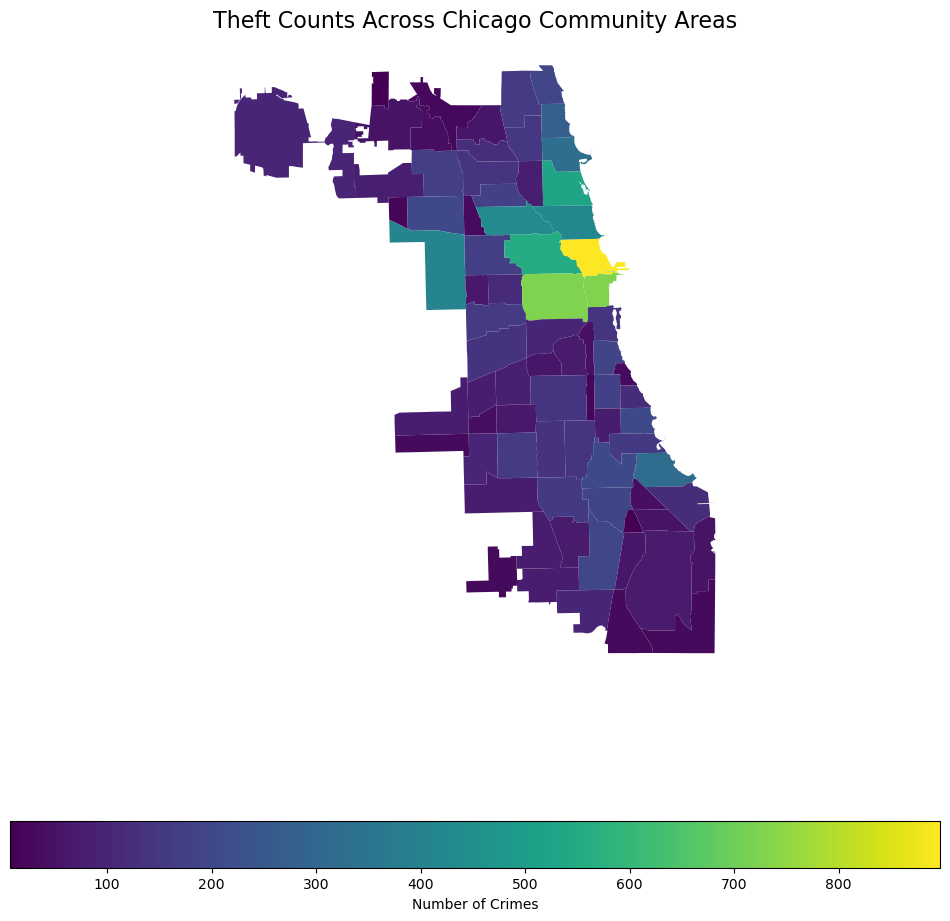

Execution logs:
Top 10 community areas with the most thefts:
           community  crime_count
36  NEAR NORTH SIDE          897
37             LOOP          728
28   NEAR WEST SIDE          725
24        WEST TOWN          556
56        LAKE VIEW          528
22     LOGAN SQUARE          428
67     LINCOLN PARK          422
25           AUSTIN          407
30           UPTOWN          329
38      SOUTH SHORE          318

Out: None

[Step 6: Duration 4.00 seconds| Input tokens: 22,153 | Output tokens: 897]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 7 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(top_10_thefts)                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer:           community  crime_count
36  NEAR NORTH SIDE          897
37             LOOP          728
28   NEAR WEST SIDE          725
24        WEST TOWN          556
56        LAKE VIEW          528
22     LOGAN SQUARE          428
67     LINCOLN PARK          422
25           AUSTIN          407
30           UPTOWN          329
38      SOUTH SHORE          318

[Step 7: Duration 2.96 seconds| Input tokens: 27,975 | Output tokens: 1,072]

,community,crime_count
36,NEAR NORTH SIDE,897
37,LOOP,728
28,NEAR WEST SIDE,725
24,WEST TOWN,556
56,LAKE VIEW,528
22,LOGAN SQUARE,428
67,LINCOLN PARK,422
25,AUSTIN,407
30,UPTOWN,329
38,SOUTH SHORE,318


In [22]:
agent.run(
    "I want to analyze theft in Chicago. First, load the community area boundaries and the latest crime data. "
    "Then, isolate only the crimes that are of the primary type 'THEFT'. "
    "Next, determine how many of these thefts occurred in each community area. "
    "Finally, list the top 10 community areas with the most thefts and create a map that visualizes the theft counts across all of Chicago."
)

In [48]:
agent.run(
    "Find open-source datasets and research papers about aging dams. "
    "Analyze the results and present them in a table."
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find open-source datasets and research papers about aging dams. Analyze the results and present them in a       │
│ table.                                                                                                          │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  datasets_and_papers = search_geospatial_resources(topic="aging dams", resource_type="datasets")                  
  print("Datasets and Research Papers Found:", datasets_and_papers)                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Datasets and Research Papers Found: [{'title': 'A living database for information on dying dams', 'href': 
'https://www.usgs.gov/centers/community-for-data-integration-cdi/science/national-dam-removal-database-a-living-dat
abase', 'body': 'National Dam Removal Database: A living database for information on dying dams . Completed By 
Community for Data Integration (CDI) April 7, 2015'}, {'title': 'National Inventory of Dams', 'href': 
'https://nid.sec.usace.army.mil/', 'body': "The National Inventory of Dam's core mapping data can be used in GIS 
desktop and web apps via the Web- GIS Service URLs below. Use these services to add NID ..."}, {'title': 'Guiding 
decisions on the future of dams: A GIS database ...', 'href': 
'https://www.sciencedirect.com/science/article/abs/pii/S0301479723024714', 'body': 'by JR Parent · 2024 · Cited by 
8 — The web map allows users to query the dams by their ecological rankings and view the ecological and social 
metrics for dams of interest.'}, {'title': 'Vulnerability Analysis for Aging Dam Infrastructure - I-GUIDE', 'href':
'https://i-guide.io/projects/vulnerability-analysis-for-aging-dam-infrastructure/', 'body': 'This includes a 
spatially specific analysis of the climate changes of concern, of what is likely to be impacted if the dams fail, 
of the cascading effects of ...'}, {'title': '(Single) Dam Failures Analysis Output - I-GUIDE Aging ...', 'href': 
'https://www.hydroshare.org/resource/5f7630be4bef40c5bd30d2e4aec6848a/', 'body': 'Sep 3, 2023 — To better 
understand this spatial variability, we categorized the dams into five clusters based on at-risk population 
characteristics. We find ...'}]

Out: None

[Step 1: Duration 3.06 seconds| Input tokens: 2,526 | Output tokens: 112]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(markdown_table)                                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 
| Title                                                                                   | Link                   
| Description                                                                                                      
|
|-----------------------------------------------------------------------------------------|------------------------
-------------------------------------------------------------------------|-----------------------------------------
-------------------------------------------------------------------------------------------------------------------
--|
| A living database for information on dying dams                                         | 
[Link](https://www.usgs.gov/centers/community-for-data-integration-cdi/science/national-dam-removal-database-a-livi
ng-database) | National Dam Removal Database: A living database for information on dying dams. Completed By 
Community for Data Integration (CDI) April 7, 2015           |
| National Inventory of Dams                                                             | 
[Link](https://nid.sec.usace.army.mil/)                                                    | The National Inventory
of Dam's core mapping data can be used in GIS applications.                                                        
|
| Guiding decisions on the future of dams: A GIS database                               | 
[Link](https://www.sciencedirect.com/science/article/abs/pii/S0301479723024714)               | A web map that 
allows users to query dams by ecological rankings and view social metrics.                                         
|
| Vulnerability Analysis for Aging Dam Infrastructure - I-GUIDE                         | 
[Link](https://i-guide.io/projects/vulnerability-analysis-for-aging-dam-infrastructure/)   | A spatially specific 
analysis of climate changes impacting dam failures and the cascading effects.                                      
|
| (Single) Dam Failures Analysis Output - I-GUIDE Aging                                 | 
[Link](https://www.hydroshare.org/resource/5f7630be4bef40c5bd30d2e4aec6848a/)              | To understand spatial 
variability, dams were categorized into five clusters based on at-risk population characteristics.                 
|

[Step 5: Duration 1.71 seconds| Input tokens: 21,718 | Output tokens: 1,601]

"\n| Title                                                                                   | Link                                                                                            | Description                                                                                                                                                  |\n|-----------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------|\n| A living database for information on dying dams                                         | [Link](https://www.usgs.gov/centers/community-for-data-integration-cdi/science/national-dam-removal-database-a-living-database) | National Dam Removal Database: A living database for information on dying d